## 1. Instalação de Dependências

In [1]:
# Forçando versões específicas para garantir compatibilidade binária e evitar o erro 'dtype size changed'
!pip install --upgrade -q "numpy>=2.0.2" "pandas==2.2.2"
!pip install -q networkx gensim node2vec matplotlib scikit-learn tqdm requests

print("✅ Dependências instaladas!")
print("⚠️ AÇÃO OBRIGATÓRIA: Clique em 'Runtime' -> 'Restart Session' (Reiniciar Sessão) no menu superior para aplicar as atualizações.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-

## 2. Imports e Configuração

In [13]:
# Adicionando gen9ubers para suportar Koraidon e Flutter Mane
import requests
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
from gensim.models import Word2Vec
from node2vec import Node2Vec
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

SMOGON_BASE = "https://www.smogon.com/stats"
OUTPUT_DIR = Path("team_recommender")
OUTPUT_DIR.mkdir(exist_ok=True)

FORMATS = {
    "gen9ou": ["2026-04", "2026-03"],
    "gen9ubers": ["2026-04", "2026-03"], # Adicionado para Koraidon/Flutter Mane
    "gen8ou": ["2026-04"],
    "gen7ou": ["2026-04"],
}
RATING = 1500

print("📋 Configuração atualizada para incluir Ubers!")

📋 Configuração atualizada para incluir Ubers!


## 3. Download dos Dados do SmogonOs dados chaos do Smogon contêm:- **usage**: taxa de uso de cada Pokémon- **Teammates**: co-ocorrência com outros Pokémon (fundamental para nosso grafo)- **Moves, Abilities, Items**: detalhes de sets competitivos

In [14]:
def download_chaos_data(format_name, month, rating=1500):
    """Download do JSON chaos do Smogon para um formato/mês específico."""
    url = f"{SMOGON_BASE}/{month}/chaos/{format_name}-{rating}.json"
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        return resp.json()
    except:
        url = f"{SMOGON_BASE}/{month}/chaos/{format_name}-0.json"
        try:
            resp = requests.get(url, timeout=60)
            resp.raise_for_status()
            return resp.json()
        except:
            return None

print("🔄 Baixando dados atualizados (OU + Ubers)... ")
all_chaos_data = {}

for fmt, months in tqdm(FORMATS.items(), desc="Formatos"):
    for month in months:
        key = f"{fmt}_{month}"
        data = download_chaos_data(fmt, month, RATING)
        if data and "data" in data:
            all_chaos_data[key] = data
            print(f"  ✅ {key}: {len(data['data'])} Pokémon")
            break

# Re-extrair e re-treinar automaticamente
print("\n🔄 Atualizando grafo e embeddings...")
all_edges = defaultdict(float)
all_pokemon_usage = defaultdict(float)

for key, chaos_data in all_chaos_data.items():
    edges, usage = extract_teammates(chaos_data, key.split("_")[0])
    for edge, weight in edges.items(): all_edges[edge] += weight
    for poke, u in usage.items(): all_pokemon_usage[poke] = max(all_pokemon_usage[poke], u)

G = nx.Graph()
for pokemon, usage in all_pokemon_usage.items(): G.add_node(pokemon, usage=usage)
min_weight = np.percentile(list(all_edges.values()), 25)
for (p1, p2), weight in all_edges.items():
    if weight >= min_weight and p1 in G.nodes and p2 in G.nodes: G.add_edge(p1, p2, weight=weight)

node2vec = Node2Vec(G, dimensions=128, walk_length=30, num_walks=100, workers=2, quiet=True)
w2v_model = node2vec.fit(window=10, min_count=1, epochs=10)
pokemon_embeddings = {p: w2v_model.wv[p] for p in w2v_model.wv.index_to_key}

print(f"✅ Pronto! {len(pokemon_embeddings)} Pokémon no sistema.")

🔄 Baixando dados atualizados (OU + Ubers)... 


Formatos:   0%|          | 0/4 [00:00<?, ?it/s]

  ✅ gen9ou_2026-04: 408 Pokémon
  ✅ gen9ubers_2026-04: 507 Pokémon
  ✅ gen8ou_2026-04: 375 Pokémon
  ✅ gen7ou_2026-04: 401 Pokémon

🔄 Atualizando grafo e embeddings...
✅ Pronto! 482 Pokémon no sistema.


## 4. Extração de Dados de Co-ocorrência (Teammates)O campo `Teammates` do Smogon indica com que frequência dois Pokémon aparecem no mesmo time.Usamos isso para construir as arestas do nosso grafo.

In [4]:
def extract_teammates(chaos_data, format_name):
    """Extrai dados de teammates de um dataset chaos."""
    edges = defaultdict(float)
    pokemon_usage = {}

    data = chaos_data.get("data", {})

    for pokemon_name, pokemon_data in data.items():
        usage = pokemon_data.get("usage", 0)
        if usage < 0.001:  # Filtrar Pokémon com uso muito baixo
            continue

        # Prefixar com gen para diferenciar entre gerações
        pokemon_usage[pokemon_name] = usage
        teammates = pokemon_data.get("Teammates", {})

        for teammate, weight in teammates.items():
            if teammate in data and data[teammate].get("usage", 0) >= 0.001:
                # Criar aresta bidirecional normalizada
                edge_key = tuple(sorted([pokemon_name, teammate]))
                # weight do Smogon é a diferença percentual de uso quando junto
                edges[edge_key] += abs(weight)

    return edges, pokemon_usage

# Agregar dados de todas as gerações
print("🔄 Extraindo dados de co-ocorrência...")
all_edges = defaultdict(float)
all_pokemon_usage = defaultdict(float)

for key, chaos_data in all_chaos_data.items():
    format_name = key.split("_")[0]
    edges, usage = extract_teammates(chaos_data, format_name)
    for edge, weight in edges.items():
        all_edges[edge] += weight
    for poke, u in usage.items():
        all_pokemon_usage[poke] = max(all_pokemon_usage[poke], u)

print(f"✅ Dados agregados:")
print(f"   Pokémon únicos: {len(all_pokemon_usage)}")
print(f"   Arestas (pares): {len(all_edges)}")

# Top 20 Pokémon por uso
top_usage = sorted(all_pokemon_usage.items(), key=lambda x: x[1], reverse=True)[:20]
print(f"\n🏆 Top 20 Pokémon por uso:")
for i, (name, usage) in enumerate(top_usage):
    print(f"   #{i+1:2d} {name:<25s} | Usage: {usage:.4f}")

🔄 Extraindo dados de co-ocorrência...
✅ Dados agregados:
   Pokémon únicos: 491
   Arestas (pares): 59492

🏆 Top 20 Pokémon por uso:
   # 1 Snorlax                   | Usage: 0.9039
   # 2 Tauros                    | Usage: 0.8792
   # 3 Chansey                   | Usage: 0.7107
   # 4 Exeggutor                 | Usage: 0.6639
   # 5 Cloyster                  | Usage: 0.6076
   # 6 Zapdos                    | Usage: 0.5661
   # 7 Starmie                   | Usage: 0.5380
   # 8 Tyranitar                 | Usage: 0.5236
   # 9 Landorus-Therian          | Usage: 0.4146
   #10 Metagross                 | Usage: 0.4129
   #11 Swampert                  | Usage: 0.3624
   #12 Excadrill                 | Usage: 0.3605
   #13 Alakazam                  | Usage: 0.3550
   #14 Latias                    | Usage: 0.3366
   #15 Rhydon                    | Usage: 0.3344
   #16 Skarmory                  | Usage: 0.3335
   #17 Great Tusk                | Usage: 0.3292
   #18 Gengar                    |

## 5. Construção do Grafo de Co-ocorrênciaCada **nó** é um Pokémon e cada **aresta** representa a frequência com que dois Pokémon aparecem no mesmo time competitivo. Arestas com peso maior indicam maior sinergia.

In [5]:
# Construir grafo NetworkX
G = nx.Graph()

# Adicionar nós com atributo de uso
for pokemon, usage in all_pokemon_usage.items():
    G.add_node(pokemon, usage=usage)

# Adicionar arestas com peso (filtrar arestas fracas)
min_weight = np.percentile(list(all_edges.values()), 25)  # Remover bottom 25%
for (p1, p2), weight in all_edges.items():
    if weight >= min_weight and p1 in G.nodes and p2 in G.nodes:
        G.add_edge(p1, p2, weight=weight)

# Remover nós isolados
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

print(f"✅ Grafo construído:")
print(f"   Nós: {G.number_of_nodes()}")
print(f"   Arestas: {G.number_of_edges()}")
print(f"   Densidade: {nx.density(G):.4f}")
print(f"   Nós isolados removidos: {len(isolates)}")

# Componentes conectados
components = list(nx.connected_components(G))
print(f"   Componentes conectados: {len(components)}")
largest = max(components, key=len)
print(f"   Maior componente: {len(largest)} nós")

✅ Grafo construído:
   Nós: 491
   Arestas: 44619
   Densidade: 0.3709
   Nós isolados removidos: 0
   Componentes conectados: 1
   Maior componente: 491 nós


## 6. Visualização do Grafo (Top Pokémon)

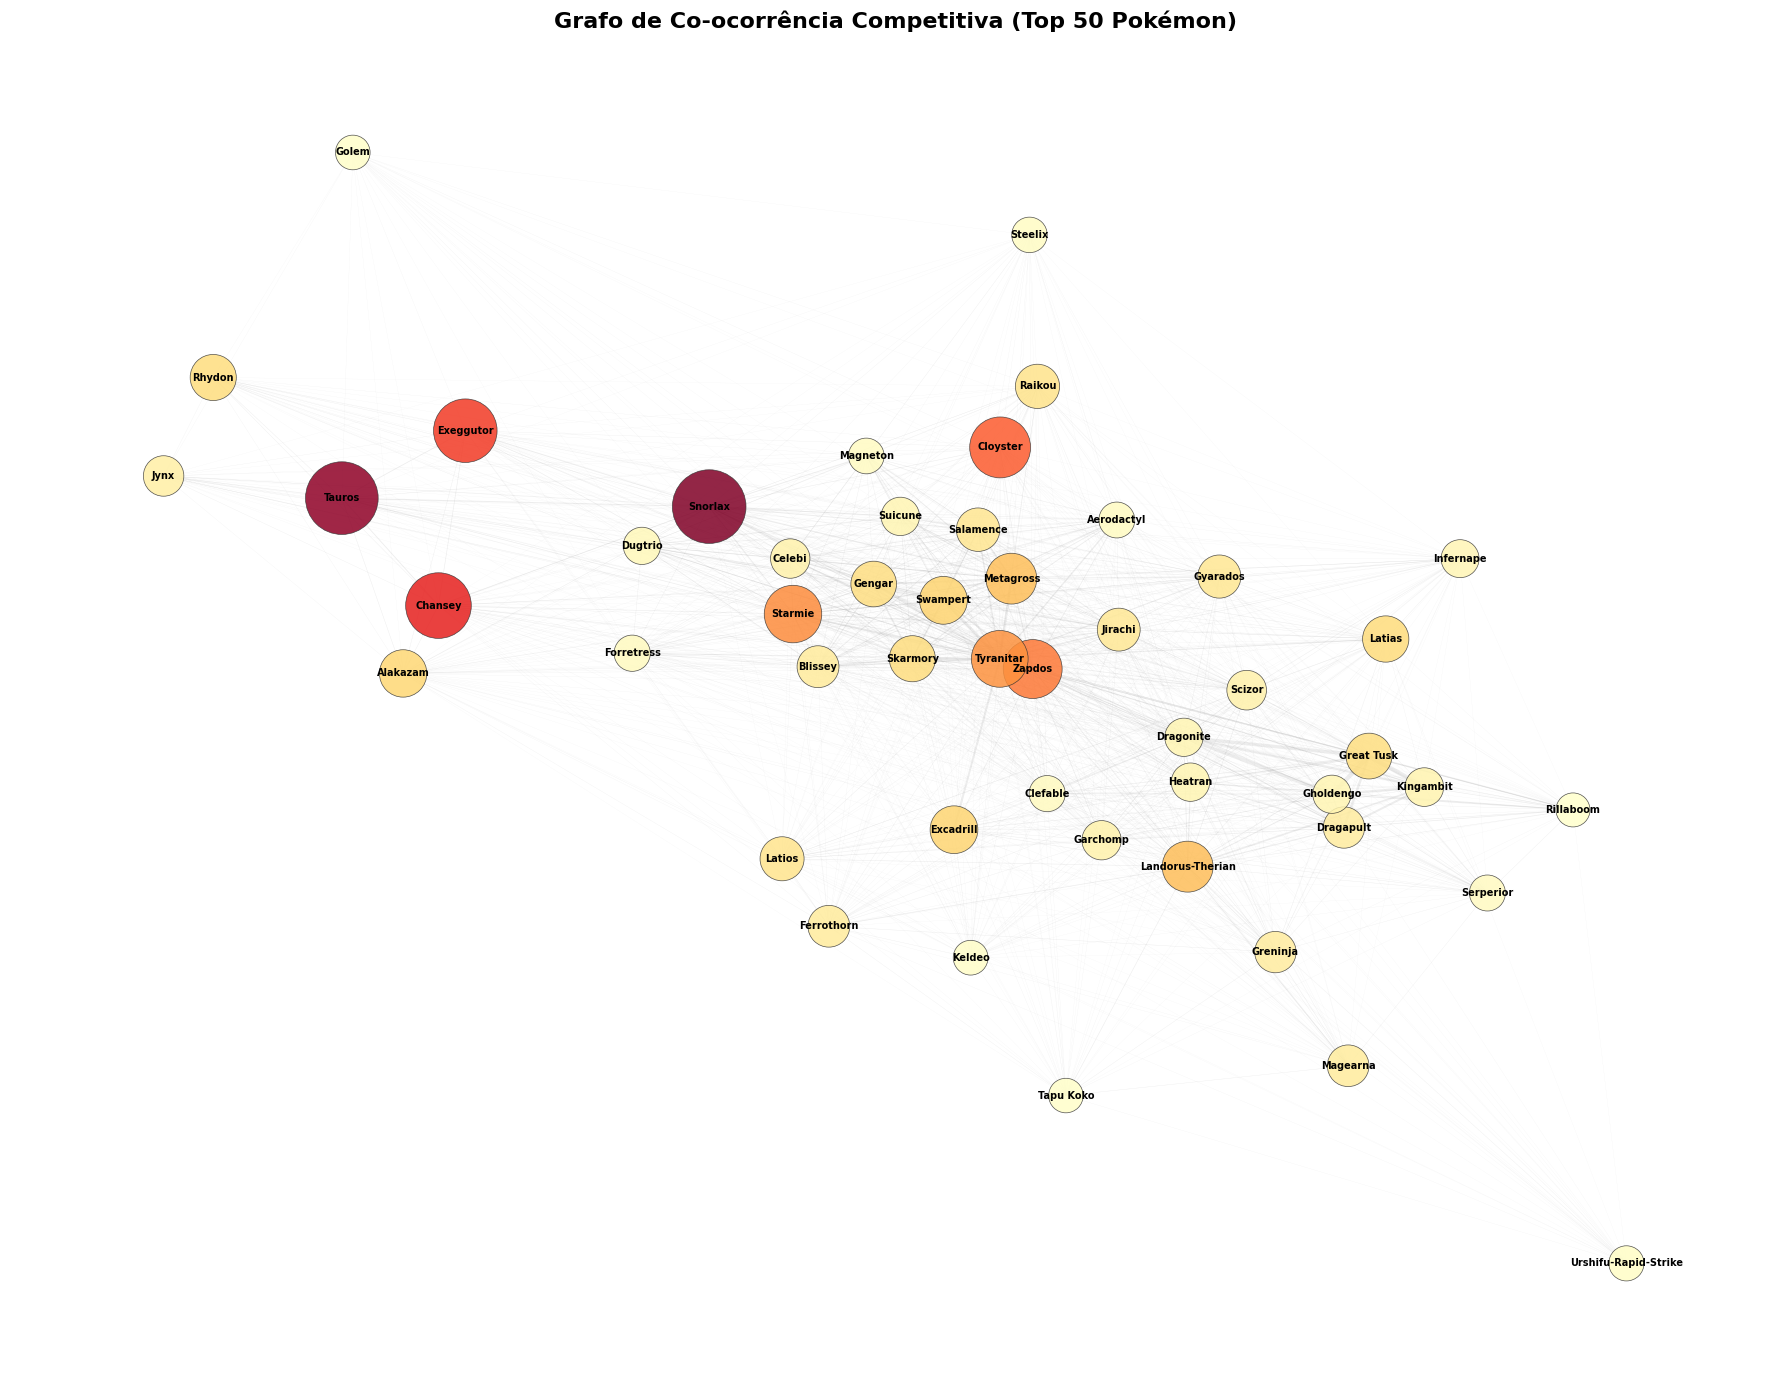

✅ Grafo salvo em team_graph.png


In [6]:
# Subgrafo com os 50 Pokémon mais usados
top_50 = [p for p, _ in sorted(all_pokemon_usage.items(), key=lambda x: x[1], reverse=True)[:50]
          if p in G.nodes]
sub_G = G.subgraph(top_50).copy()

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(sub_G, k=2, iterations=50, seed=42)

# Tamanho dos nós proporcional ao uso
node_sizes = [all_pokemon_usage.get(n, 0) * 3000 + 100 for n in sub_G.nodes()]

# Cor dos nós
node_colors = [all_pokemon_usage.get(n, 0) for n in sub_G.nodes()]

# Peso das arestas
edge_weights = [sub_G[u][v].get('weight', 1) for u, v in sub_G.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [w / max_w * 3 + 0.1 for w in edge_weights]

# Desenhar
nx.draw_networkx_edges(sub_G, pos, alpha=0.15, width=edge_widths, edge_color='#888888')
nx.draw_networkx_nodes(sub_G, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.YlOrRd, alpha=0.85, edgecolors='#333333', linewidths=0.5)
nx.draw_networkx_labels(sub_G, pos, font_size=7, font_weight='bold')

plt.title("Grafo de Co-ocorrência Competitiva (Top 50 Pokémon)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("team_graph.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafo salvo em team_graph.png")

## 7. Node2Vec: Embeddings de Grafo**Node2Vec** gera embeddings para cada nó do grafo usando random walks + Word2Vec.Parâmetros:- `dimensions=128`: dimensão dos embeddings- `walk_length=30`: comprimento de cada random walk- `num_walks=200`: número de walks por nó- `p=1, q=1`: parâmetros de busca (BFS/DFS balance)

In [7]:
# Usar apenas o maior componente conectado para Node2Vec
G_largest = G.subgraph(largest).copy()
print(f"🔄 Executando Node2Vec no maior componente ({G_largest.number_of_nodes()} nós)...")

# Configurar Node2Vec
node2vec = Node2Vec(
    G_largest,
    dimensions=128,
    walk_length=30,
    num_walks=200,
    p=1.0,
    q=1.0,
    workers=2,
    seed=42,
    quiet=False
)

# Treinar Word2Vec nos random walks
print("\n🔄 Treinando Word2Vec nos random walks...")
w2v_model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4,
    epochs=20
)

print(f"\n✅ Node2Vec concluído!")
print(f"   Vocabulário: {len(w2v_model.wv)} Pokémon")
print(f"   Dimensões: {w2v_model.wv.vector_size}")

# Criar dicionário de embeddings
pokemon_embeddings = {}
for pokemon in w2v_model.wv.index_to_key:
    pokemon_embeddings[pokemon] = w2v_model.wv[pokemon]

print(f"   Embeddings gerados: {len(pokemon_embeddings)}")

🔄 Executando Node2Vec no maior componente (491 nós)...


Computing transition probabilities:   0%|          | 0/491 [00:00<?, ?it/s]


🔄 Treinando Word2Vec nos random walks...

✅ Node2Vec concluído!
   Vocabulário: 491 Pokémon
   Dimensões: 128
   Embeddings gerados: 491


## 8. Sistema de RecomendaçãoA função `recommend_team` recebe 1+ Pokémon e sugere parceiros que complementam o time,baseando-se na similaridade dos embeddings no espaço vetorial.

In [8]:
def recommend_team(pokemon_list, team_size=6, top_candidates=10):
    """
    Recomenda Pokémon para completar um time competitivo.

    Args:
        pokemon_list: Lista de Pokémon já no time (1-5 Pokémon)
        team_size: Tamanho alvo do time (padrão: 6)
        top_candidates: Número de candidatos a mostrar para cada slot

    Returns:
        Lista de Pokémon recomendados
    """
    # Validar Pokémon de entrada
    valid_pokemon = []
    for poke in pokemon_list:
        if poke in pokemon_embeddings:
            valid_pokemon.append(poke)
        else:
            # Tentar encontrar variação do nome
            matches = [p for p in pokemon_embeddings.keys() if poke.lower() in p.lower()]
            if matches:
                valid_pokemon.append(matches[0])
                print(f"  ℹ️ '{poke}' → '{matches[0]}'")
            else:
                print(f"  ⚠️ '{poke}' não encontrado no dataset")

    if not valid_pokemon:
        print("❌ Nenhum Pokémon válido encontrado")
        return []

    # Calcular centróide do time atual
    team_vectors = np.array([pokemon_embeddings[p] for p in valid_pokemon])
    centroid = np.mean(team_vectors, axis=0).reshape(1, -1)

    # Buscar Pokémon mais similares ao centróide
    all_names = list(pokemon_embeddings.keys())
    all_vectors = np.array([pokemon_embeddings[n] for n in all_names])

    sims = cosine_similarity(centroid, all_vectors)[0]

    # Ranquear e filtrar
    ranked = sorted(zip(all_names, sims), key=lambda x: x[1], reverse=True)
    excluded = set(p.lower() for p in valid_pokemon)

    recommendations = []
    print(f"\n🎮 Time atual: {valid_pokemon}")
    print(f"{'='*60}")

    slots_needed = team_size - len(valid_pokemon)
    shown = 0
    for name, score in ranked:
        if name.lower() in excluded:
            continue
        recommendations.append({"name": name, "score": score})
        if shown < top_candidates:
            marker = "⭐" if shown < slots_needed else "  "
            print(f"  {marker} #{shown+1:2d} {name:<25s} | Sinergia: {score:.4f}")
            shown += 1
        if shown >= top_candidates:
            break

    print(f"{'='*60}")
    suggested = [r["name"] for r in recommendations[:slots_needed]]
    print(f"\n✅ Time sugerido ({team_size} Pokémon):")
    full_team = valid_pokemon + suggested
    for i, p in enumerate(full_team):
        marker = "📌" if p in valid_pokemon else "🆕"
        print(f"   {marker} {p}")

    return recommendations

print("✅ Função recommend_team() pronta!")

✅ Função recommend_team() pronta!


## 9. Exemplos Reais de Recomendação

In [20]:
poke_name = "Gothitelle"

if poke_name in pokemon_embeddings:
    print(f" {poke_name} ta no dataset!")
    valid_pokes = ["Koraidon", "Incineroar", "Amoonguss", "Scream Tail", "Flutter Mane"]
    team_vecs = np.array([pokemon_embeddings[p] for p in valid_pokes if p in pokemon_embeddings])
    centroid = np.mean(team_vecs, axis=0).reshape(1, -1)

    goth_vec = pokemon_embeddings[poke_name].reshape(1, -1)
    sim = cosine_similarity(centroid, goth_vec)[0][0]
    usage = all_pokemon_usage.get(poke_name, 0)

    print(f"Sinergia com o time: {sim:.4f}")
    print(f"Taxa de uso global: {usage:.4f}")
    print("\nNota: Se a sinergia for baixa ou o uso for muito pequeno, ela fica fora do Top 10.")
else:
    print(f" '{poke_name}' não foi encontrada nos formatos atuais (Gen 9 OU/Ubers, Gen 8, Gen 7).")
    print("Isso ocorre se o Pokémon tiver uso < 0.1% ou se a habilidade/Pokémon for banido do formato.")

print("\n" + "="*30 + " RE-EXECUTANDO TOP 20 " + "="*30)
recommend_team(["Koraidon", "Incineroar", "Amoonguss", "Scream Tail", "Flutter Mane"], top_candidates=20)

 Gothitelle ta no dataset!
Sinergia com o time: 0.3429
Taxa de uso global: 0.0019

Nota: Se a sinergia for baixa ou o uso for muito pequeno, ela fica fora do Top 10.

============================== RE-EXECUTANDO TOP 20 ==============================

🎮 Time atual: ['Koraidon', 'Incineroar', 'Amoonguss', 'Scream Tail', 'Flutter Mane']
  ⭐ # 1 Zacian-Crowned            | Sinergia: 0.7064
     # 2 Terapagos                 | Sinergia: 0.7038
     # 3 Eternatus                 | Sinergia: 0.6959
     # 4 Arceus                    | Sinergia: 0.6923
     # 5 Kyogre                    | Sinergia: 0.6857
     # 6 Ho-Oh                     | Sinergia: 0.6767
     # 7 Necrozma-Dusk-Mane        | Sinergia: 0.6739
     # 8 Chien-Pao                 | Sinergia: 0.6583
     # 9 Deoxys-Attack             | Sinergia: 0.6562
     #10 Giratina-Origin           | Sinergia: 0.6512
     #11 Arceus-Ground             | Sinergia: 0.6455
     #12 Groudon                   | Sinergia: 0.6408
     #13 Ogerpon-

[{'name': 'Zacian-Crowned', 'score': 0.7063675},
 {'name': 'Terapagos', 'score': 0.70377415},
 {'name': 'Eternatus', 'score': 0.6958754},
 {'name': 'Arceus', 'score': 0.69228166},
 {'name': 'Kyogre', 'score': 0.6857214},
 {'name': 'Ho-Oh', 'score': 0.67671007},
 {'name': 'Necrozma-Dusk-Mane', 'score': 0.67391586},
 {'name': 'Chien-Pao', 'score': 0.6583158},
 {'name': 'Deoxys-Attack', 'score': 0.65618235},
 {'name': 'Giratina-Origin', 'score': 0.65123165},
 {'name': 'Arceus-Ground', 'score': 0.6454948},
 {'name': 'Groudon', 'score': 0.6408292},
 {'name': 'Ogerpon-Hearthflame', 'score': 0.62763405},
 {'name': 'Chi-Yu', 'score': 0.6206408},
 {'name': 'Sneasler', 'score': 0.6201778},
 {'name': 'Arceus-Dragon', 'score': 0.6160961},
 {'name': 'Rayquaza', 'score': 0.615308},
 {'name': 'Lunala', 'score': 0.6152379},
 {'name': 'Roaring Moon', 'score': 0.6096849},
 {'name': 'Arceus-Water', 'score': 0.60380423}]

### 🔍 Busca de Nomes no Dataset
Use esta célula para encontrar a grafia exata de um Pokémon caso o sistema não o reconheça.

In [12]:
def search_pokemon(query):
    query = query.lower()
    results = [name for name in pokemon_embeddings.keys() if query in name.lower()]
    if results:
        print(f"✅ Resultados para '{query}':")
        for r in results: print(f"   - {r}")
    else:
        print(f"❌ Nenhum Pokémon encontrado com '{query}'")

# Vamos procurar pelos que falharam
print("Buscando termos próximos:")
search_pokemon("Koraidon")
search_pokemon("Flutter")
search_pokemon("Amoong")

Buscando termos próximos:
❌ Nenhum Pokémon encontrado com 'koraidon'
❌ Nenhum Pokémon encontrado com 'flutter'
✅ Resultados para 'amoong':
   - Amoonguss


## 10. Visualização dos Embeddings

🔄 Calculando t-SNE para embeddings Node2Vec...


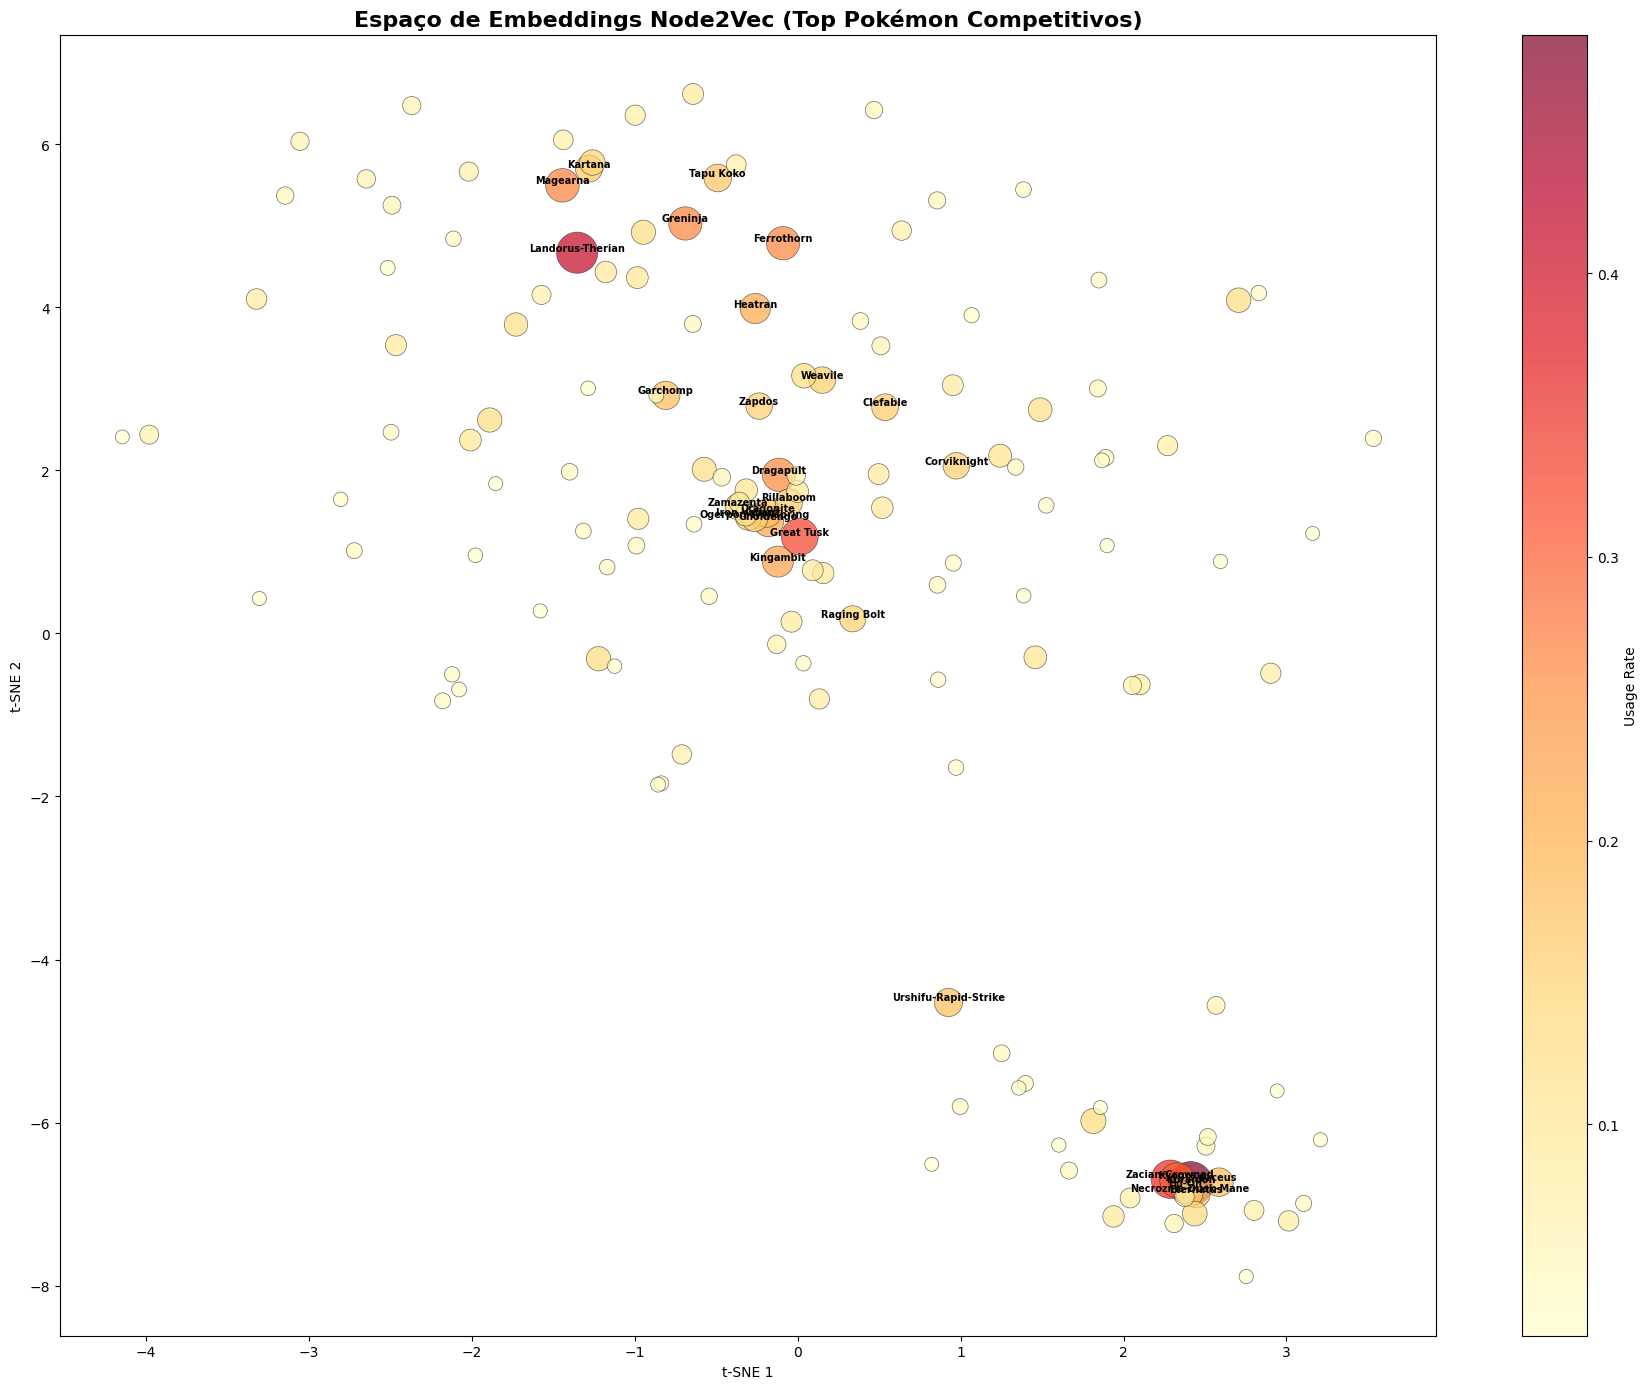

✅ Visualização salva em node2vec_tsne.png


In [21]:
# Visualizar embeddings com t-SNE
print("🔄 Calculando t-SNE para embeddings Node2Vec...")

names = list(pokemon_embeddings.keys())
vectors = np.array([pokemon_embeddings[n] for n in names])

# Selecionar top Pokémon por uso para visualização limpa
top_n = min(150, len(names))
top_indices = sorted(range(len(names)), key=lambda i: all_pokemon_usage.get(names[i], 0), reverse=True)[:top_n]
top_names = [names[i] for i in top_indices]
top_vectors = vectors[top_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, top_n-1), n_iter=1000)
coords = tsne.fit_transform(top_vectors)

plt.figure(figsize=(18, 14))
usages = [all_pokemon_usage.get(n, 0) for n in top_names]
sizes = [u * 2000 + 50 for u in usages]

scatter = plt.scatter(coords[:, 0], coords[:, 1], c=usages, cmap='YlOrRd',
                     s=sizes, alpha=0.7, edgecolors='#333', linewidth=0.5)

# Anotar os top 30
for i in range(min(30, len(top_names))):
    plt.annotate(top_names[i], (coords[i, 0], coords[i, 1]),
                fontsize=7, fontweight='bold', ha='center', va='bottom')

plt.colorbar(scatter, label='Usage Rate')
plt.title("Espaço de Embeddings Node2Vec (Top Pokémon Competitivos)", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("node2vec_tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualização salva em node2vec_tsne.png")

## 11. Exportação do Modelo

In [22]:
import pickle

# Salvar modelo e embeddings
w2v_model.save(str(OUTPUT_DIR / "node2vec_model.w2v"))

# Salvar embeddings como numpy
np.savez(
    str(OUTPUT_DIR / "pokemon_embeddings.npz"),
    names=np.array(list(pokemon_embeddings.keys())),
    vectors=np.array(list(pokemon_embeddings.values()))
)

# Salvar grafo usando pickle (substituindo o write_gpickle que foi removido no NetworkX 3.0)
with open(OUTPUT_DIR / "cooccurrence_graph.pkl", "wb") as f:
    pickle.dump(G, f)

# Salvar usage stats
pd.DataFrame(list(all_pokemon_usage.items()), columns=["pokemon", "usage"]) \
    .sort_values("usage", ascending=False) \
    .to_csv(str(OUTPUT_DIR / "usage_stats.csv"), index=False)

print("✅ Arquivos exportados:")
for f in OUTPUT_DIR.iterdir():
    size = f.stat().st_size / 1024
    print(f"   📁 {f.name} ({size:.1f} KB)")

!cd team_recommender && zip -r ../team_recommender.zip .
print("\n📦 Compactado: team_recommender.zip")

✅ Arquivos exportados:
   📁 pokemon_embeddings.npz (279.2 KB)
   📁 usage_stats.csv (10.8 KB)
   📁 cooccurrence_graph.pkl (1490.6 KB)
   📁 node2vec_model.w2v (501.9 KB)
  adding: pokemon_embeddings.npz (deflated 18%)
  adding: usage_stats.csv (deflated 54%)
  adding: cooccurrence_graph.pkl (deflated 54%)
  adding: node2vec_model.w2v (deflated 9%)

📦 Compactado: team_recommender.zip
